# 04: Temporal Deterioration and Classification Model

In [ ]:
# Uncomment and run if you are missing these libraries
!pip install -q imbalanced-learn tensorflow


In [15]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import pickle

# Configuration
data_dir = r'C:\Users\Kruthi K Shetty\data-science\data'
models_dir = r'C:\Users\Kruthi K Shetty\data-science\models'
os.makedirs(models_dir, exist_ok=True)

df_path = os.path.join(data_dir, 'features_df.csv')
risk_out_path = os.path.join(data_dir, 'patient_risk_scores.csv')

print("Loading features dataset...")
df = pd.read_csv(df_path)
print(f"Dataset shape: {df.shape}")

# Identify feature columns (everything except metadata)
meta_cols = ['npy_index', 'patient_id', 'filename', 'cycle_start', 'cycle_end', 'label']
feature_cols = [c for c in df.columns if c not in meta_cols]
print(f"Number of audio features identified: {len(feature_cols)}")


Loading features dataset...
Dataset shape: (6869, 82)
Number of audio features identified: 76


In [16]:
# PART A: Temporal Deterioration Analysis

# Sort by patient and then by cycle start time to ensure chronological order
df_sorted = df.sort_values(by=['patient_id', 'cycle_start']).copy()

patient_risk_data = []

# Group by patient
grouped = df_sorted.groupby('patient_id')

print(f"Analyzing deterioration for {len(grouped)} patients...")

for patient_id, group in grouped:
    # We need at least 2 cycles to compute a slope
    if len(group) < 2:
        # If only 1 cycle, slope is 0
        slopes = np.zeros(len(feature_cols))
    else:
        slopes = []
        # X-axis is the cycle index (0, 1, 2, ...) to represent time progression
        x = np.arange(len(group))
        for feature in feature_cols:
            y = group[feature].values
            slope, _, _, _, _ = linregress(x, y)
            slopes.append(slope)
        slopes = np.array(slopes)
        
    # Replace any NaNs with 0 (can happen if variance is perfectly 0)
    slopes = np.nan_to_num(slopes)
    
    # Calculate L2 norm of the deterioration vector
    l2_norm = np.linalg.norm(slopes)
    
    # Determine dominant label for this patient
    dominant_label = group['label'].mode()[0]
    
    patient_risk_data.append({
        'patient_id': patient_id,
        'l2_norm': l2_norm,
        'dominant_label': dominant_label,
        'num_cycles': len(group)
    })

risk_df = pd.DataFrame(patient_risk_data)


Analyzing deterioration for 126 patients...


In [17]:
# Normalize L2 norms to a 0-100 Risk Score
scaler = MinMaxScaler(feature_range=(0, 100))
risk_df['risk_score'] = scaler.fit_transform(risk_df[['l2_norm']])

# Save to CSV
risk_df.to_csv(risk_out_path, index=False)
print(f"Saved patient risk scores to {risk_out_path}")

risk_df.sort_values('risk_score', ascending=False).head()


Saved patient risk scores to C:\Users\Kruthi K Shetty\data-science\data\patient_risk_scores.csv


,patient_id,l2_norm,dominant_label,num_cycles,risk_score
88,189,167.348036,Normal,5,100.000000
27,128,155.198034,Crackle,5,92.733372
89,190,142.143872,Normal,4,84.925987
24,125,105.992460,Normal,6,63.304683
54,155,79.767830,Normal,6,47.620353


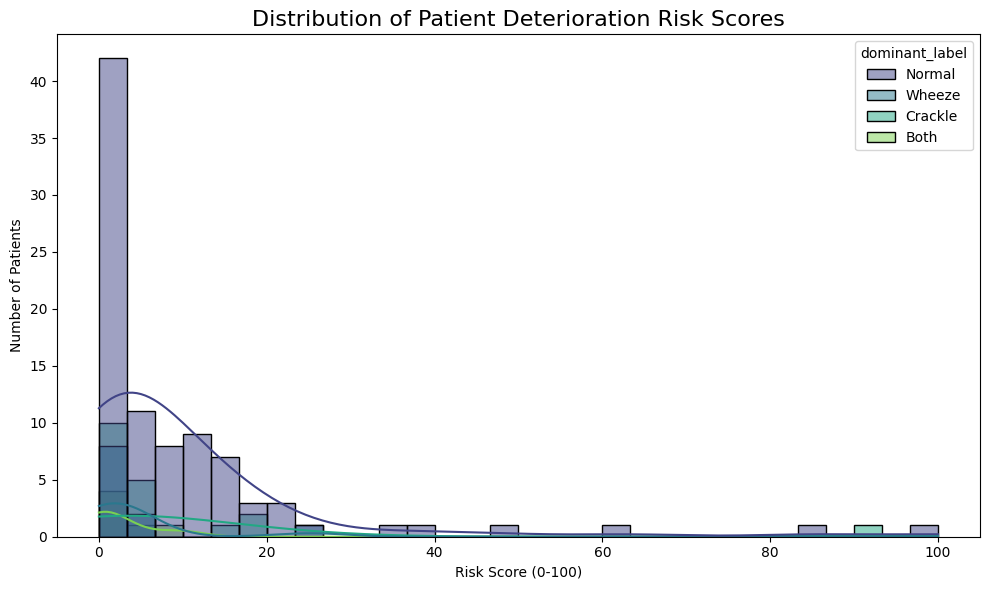

In [18]:
# Plot histogram of risk scores colored by dominant label
plt.figure(figsize=(10, 6))
sns.histplot(data=risk_df, x='risk_score', hue='dominant_label', bins=30, kde=True, palette='viridis')
plt.title('Distribution of Patient Deterioration Risk Scores', fontsize=16)
plt.xlabel('Risk Score (0-100)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()


In [19]:
# PART B: Cycle-Level Classification Model
from sklearn.preprocessing import StandardScaler
# Prepare X and y
X = df[feature_cols].values
y_text = df['label'].values

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y_text)
# Normal=0, Crackle=1, Wheeze=2, Both=3 (order may vary based on alphabetical sorting, so we print the mapping)

print("Label Mapping:")
for i, cls in enumerate(le.classes_):
    print(f"{i} -> {cls}")

# Train/Test Split (80/20 Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42)
# Scale the features using StandardScaler (Crucial for Neural Networks!)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
print(f"\nTrain set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Label Mapping:
0 -> Both
1 -> Crackle
2 -> Normal
3 -> Wheeze

Train set: (5495, 76)
Test set: (1374, 76)


In [20]:
# Apply SMOTE to the training set only
print("Class distribution before SMOTE:")
unique, counts = np.unique(y_train, return_counts=True)
print(dict(zip(le.inverse_transform(unique), counts)))

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nClass distribution after SMOTE:")
unique, counts = np.unique(y_train_smote, return_counts=True)
print(dict(zip(le.inverse_transform(unique), counts)))


Class distribution before SMOTE:
{'Both': np.int64(399), 'Crackle': np.int64(1488), 'Normal': np.int64(2902), 'Wheeze': np.int64(706)}

Class distribution after SMOTE:
{'Both': np.int64(2902), 'Crackle': np.int64(2902), 'Normal': np.int64(2902), 'Wheeze': np.int64(2902)}


In [26]:
# Build the Keras Neural Network
num_classes = len(le.classes_)
input_dim = X_train.shape[1]

model = Sequential([
    Dense(128, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])

model.summary()

# Train with EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

print("\nStarting training...")
history = model.fit(
    X_train_smote, y_train_smote,
    epochs=100,
    batch_size=64,
    validation_data=(X_test, y_test), # Validate on real unseen data!
    callbacks=[early_stop],
    verbose=1
)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 128)            │         9,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,372 (71.77 KB)

 Trainable params: 18,372 (71.77 KB)

 Non-trainable params: 0 (0.00 B)


Starting training...
Epoch 1/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.3918 - loss: 1.3014 - val_accuracy: 0.4629 - val_loss: 1.1935
Epoch 2/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4600 - loss: 1.1866 - val_accuracy: 0.4592 - val_loss: 1.1658
Epoch 3/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4916 - loss: 1.1382 - val_accuracy: 0.4869 - val_loss: 1.1320
Epoch 4/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5151 - loss: 1.0973 - val_accuracy: 0.4694 - val_loss: 1.1373
Epoch 5/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5395 - loss: 1.0626 - val_accuracy: 0.4614 - val_loss: 1.1529
Epoch 6/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5471 - loss: 1.0426 - val_accuracy: 0.4898 - val_loss: 1.1072
Epoch 7/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5734 - loss: 1.0027 - val_accuracy: 0.5124 - val_loss: 1.0762
Epoch 8/100
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5793 - l

In [27]:
# Evaluate on the completely unseen TEST set
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Calculate ICBHI Score: (Sensitivity + Specificity) / 2
cm = confusion_matrix(y_test, y_pred)
icbhi_scores = {}

for i, cls in enumerate(le.classes_):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - (TP + FP + FN)
    
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    icbhi_score = (sensitivity + specificity) / 2
    icbhi_scores[cls] = icbhi_score

print("ICBHI Scores per class:")
for cls, score in icbhi_scores.items():
    print(f"{cls}: {score:.4f}")

macro_icbhi = np.mean(list(icbhi_scores.values()))
print(f"\nMACRO AVERAGE ICBHI SCORE: {macro_icbhi:.4f}")


43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

Classification Report:
              precision    recall  f1-score   support

        Both       0.28      0.31      0.29       100
     Crackle       0.53      0.52      0.53       372
      Normal       0.73      0.63      0.68       725
      Wheeze       0.35      0.54      0.43       177

    accuracy                           0.57      1374
   macro avg       0.47      0.50      0.48      1374
weighted avg       0.59      0.57      0.57      1374

ICBHI Scores per class:
Both: 0.6236
Crackle: 0.6749
Normal: 0.6827
Wheeze: 0.6961

MACRO AVERAGE ICBHI SCORE: 0.6693


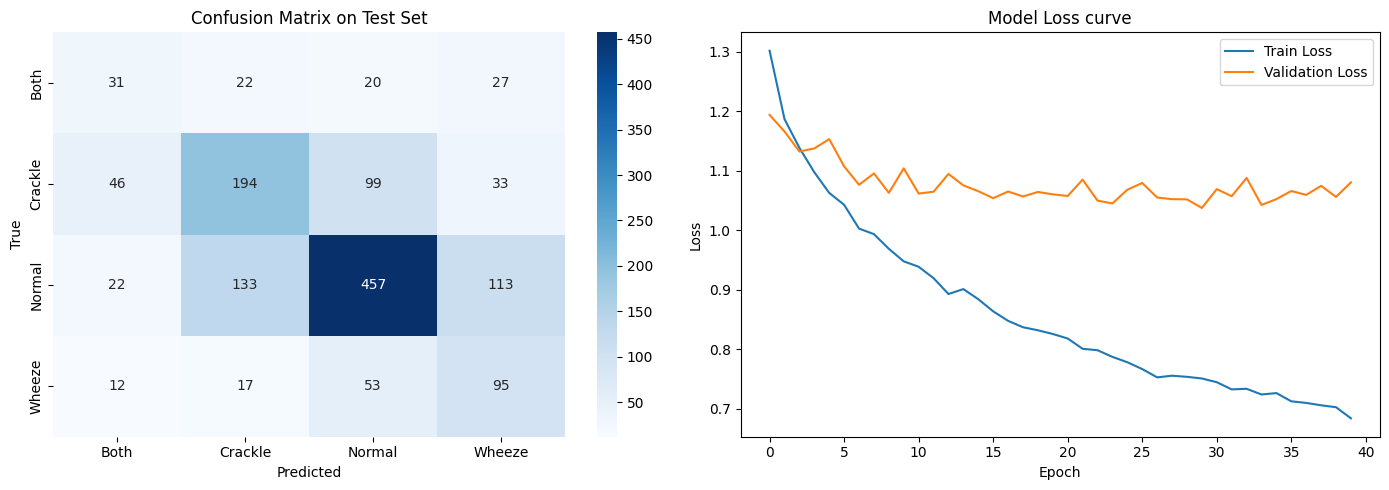

In [28]:
# Plot Confusion Matrix
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix on Test Set')
plt.xlabel('Predicted')
plt.ylabel('True')

# Plot Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [29]:
# Save the trained model
model_path = os.path.join(models_dir, 'lung_model.keras')
model.save(model_path)
print(f"Saved model to {model_path}")

# Save the label encoder
le_path = os.path.join(models_dir, 'label_encoder.pkl')
with open(le_path, 'wb') as f:
    pickle.dump(le, f)
print(f"Saved label encoder to {le_path}")

# Save the test set for future use (Notebook 5)
test_set_path = os.path.join(data_dir, 'test_set.pkl')
with open(test_set_path, 'wb') as f:
    pickle.dump({'X_test': X_test, 'y_test': y_test}, f)
print(f"Saved test set to {test_set_path}")


Saved model to C:\Users\Kruthi K Shetty\data-science\models\lung_model.keras
Saved label encoder to C:\Users\Kruthi K Shetty\data-science\models\label_encoder.pkl
Saved test set to C:\Users\Kruthi K Shetty\data-science\data\test_set.pkl
